# Analisis a Grupo de Whatsapp

En esta libreta vamos a experimentar con un grupo de Whatsapp.

In [ ]:
import regex
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import os

SOURCE = Path("..") / "data" / "Group" / 'Group.txt'

with open(SOURCE, 'r') as file:
    content = file.read()
# raw_data = regex.sub(r'\p{Cf}', '', content)
#print(test)
raw_data = content.split("\n")
print(f"Numero de Mensajes {len(raw_data)}")

Numero de Mensajes 6809


## Formateo

In [2]:
data = {
    "Date": [],
    "Time": [],
    "Text": []
}

for n, rd in enumerate(raw_data):
    v = rd.split(" - ")
    if len(v)==2:
        datetime = v[0].split(",")
        try:
            # print("DATA", v)
            # print("DATETIME", datetime)
            date = pd.to_datetime(datetime[0])
            time = datetime[1].lstrip()
            q = [date, time, [v[1]]]
        except:
            q[-1] += v
    else:
        e = v[0]
        if not e=="":
            q[-1].append(e)
            # print("QF", q)
    data['Date'].append(q[0])
    data['Time'].append(q[1])
    data['Text'].append(q[2])

history = pd.DataFrame.from_dict(data)
print(history)

           Date   Time                                               Text
0    2026-01-07  13:06  [Messages and calls are end-to-end encrypted. ...
1    2025-01-20  09:29  [+52 662 427 4882 created group "Prepa TecMile...
2    2026-01-07  13:06        [You joined using this group's invite link]
3    2026-01-07  13:08              [~ Victor joined using a group link.]
4    2026-01-07  13:12  [+52 662 371 7064: IMG-20260107-WA0001.jpg (fi...
...         ...    ...                                                ...
6804 2026-08-06  17:21  [+52 662 373 0428 changed their phone number t...
6805 2026-08-07  08:04             [Paulina TEC removed +52 662 287 1905]
6806 2026-08-07  08:04             [Paulina TEC removed +52 662 327 5070]
6807 2026-08-07  08:05                          [Paulina TEC removed you]
6808 2026-08-07  08:05                          [Paulina TEC removed you]

[6809 rows x 3 columns]


### Año y Mes de los mensajes.

In [3]:
history['Year'] = history['Date'].dt.year
history['Month'] = history['Date'].dt.month
history.head(n=10)

,Date,Time,Text,Year,Month
0,2026-01-07,13:06,[Messages and calls are end-to-end encrypted. ...,2026,1
1,2025-01-20,09:29,"[+52 662 427 4882 created group ""Prepa TecMile...",2025,1
2,2026-01-07,13:06,[You joined using this group's invite link],2026,1
3,2026-01-07,13:08,[~ Victor joined using a group link.],2026,1
4,2026-01-07,13:12,[+52 662 371 7064: IMG-20260107-WA0001.jpg (fi...,2026,1
5,2026-01-07,13:45,[Paulina TEC removed +52 662 107 7744],2026,1
6,2026-01-07,13:45,[Paulina TEC removed +52 662 140 8142],2026,1
7,2026-01-07,13:45,[Paulina TEC removed +52 644 455 6377],2026,1
8,2026-01-07,13:46,[Paulina TEC removed +52 662 299 7789],2026,1
9,2026-01-07,13:57,[~ Aarón Morales joined using a group link.],2026,1


### Filtro por año.

Para este analisis revisaremos el año 2025.

In [4]:
history_25 = history[history['Year']==2025]
history_26 = history[history['Year']==2026]

#### Mensajes durante el 2026

<BarContainer object of 8 artists>

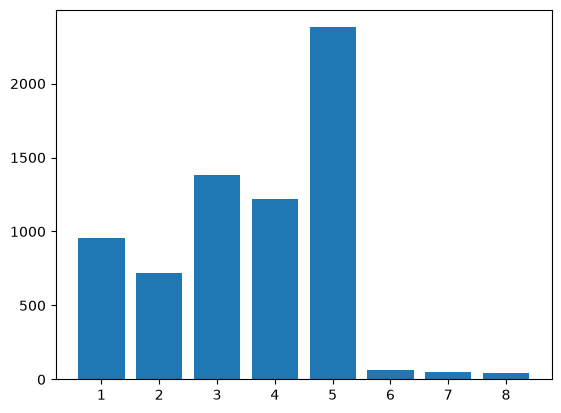

In [5]:
monthly_chats = history_26.value_counts('Month').sort_index()
plt.bar([x for x in range(1,9)], monthly_chats)

## Anonimato

Parte importante de este analisis es el anonimizar los datos. Primero vamos a extraer a los remitentes.

In [6]:
history_26['Sender'] = history_26['Text'].apply(lambda x: x[0].split(":")[0] if len(x[0].split(":")) == 2 else None)
#history_26

Extraimos la lista de usarios que enviaron mensajes para darles un código.

In [7]:
senders = history_26['Sender'].unique()[1:]
#senders

In [8]:
import numpy as np
analysis_id = np.random.choice(100, len(senders), replace=False)
new_id = {u: f"ID{int(analysis_id[k])}" for k, u in enumerate(senders)}

def set_nid(x, d=new_id):
    try:
        y = d[x]
        return y
    except:
        pass

history_26['Sender']=history_26['Sender'].apply(lambda x: set_nid(x))
history_26.head(n=10)

,Date,Time,Text,Year,Month,Sender
0,2026-01-07,13:06,[Messages and calls are end-to-end encrypted. ...,2026,1,NaN
2,2026-01-07,13:06,[You joined using this group's invite link],2026,1,NaN
3,2026-01-07,13:08,[~ Victor joined using a group link.],2026,1,NaN
4,2026-01-07,13:12,[+52 662 371 7064: IMG-20260107-WA0001.jpg (fi...,2026,1,ID21
5,2026-01-07,13:45,[Paulina TEC removed +52 662 107 7744],2026,1,NaN
6,2026-01-07,13:45,[Paulina TEC removed +52 662 140 8142],2026,1,NaN
7,2026-01-07,13:45,[Paulina TEC removed +52 644 455 6377],2026,1,NaN
8,2026-01-07,13:46,[Paulina TEC removed +52 662 299 7789],2026,1,NaN
9,2026-01-07,13:57,[~ Aarón Morales joined using a group link.],2026,1,NaN
10,2026-01-07,14:24,[~ Adriana Rubio joined using a group link.],2026,1,NaN


In [9]:
value = []
v0 = history_26['Text']
for name in new_id.keys():
    q = []
    for v in v0:
        line = []
        for lv in v:
            an_line = lv.replace(name, new_id[name])
            line.append(an_line)
        if len(v) != len(line):
            print(v, line)
        q.append(line)
    v0 = q.copy()
history_26['Text'] = v0.copy()
history_26

,Date,Time,Text,Year,Month,Sender
0,2026-01-07,13:06,[Messages and calls are end-to-end encrypted. ...,2026,1,NaN
2,2026-01-07,13:06,[You joined using this group's invite link],2026,1,NaN
3,2026-01-07,13:08,[~ Victor joined using a group link.],2026,1,NaN
4,2026-01-07,13:12,[ID21: IMG-20260107-WA0001.jpg (file attached)],2026,1,ID21
5,2026-01-07,13:45,[ID99 removed +52 662 107 7744],2026,1,NaN
...,...,...,...,...,...,...
6804,2026-08-06,17:21,[ID45 changed their phone number to a new numb...,2026,8,NaN
6805,2026-08-07,08:04,[ID99 removed ID38],2026,8,NaN
6806,2026-08-07,08:04,[ID99 removed ID48],2026,8,NaN
6807,2026-08-07,08:05,[ID99 removed you],2026,8,NaN


## Mensajes enviados.

Vemos que el mes de mayo fue el más activo del grupo. Ahora veremos el usuario que más mensajes envio.

In [10]:
top_messages= history_26["Sender"].value_counts(normalize=True) * 100
top_messages

Sender
ID99    12.750397
ID44     7.297297
ID5      4.260731
ID62     4.101749
ID16     3.545310
          ...    
ID97     0.063593
ID85     0.047695
ID86     0.031797
ID83     0.015898
ID26     0.015898
Name: proportion, Length: 77, dtype: float64

Vemos como el usuario identificado como ID16 con casi el 13% de los mensajes y el ID53 fue el que menos mensajes envio con menos del 1%.

## Numero de palabras promedios por usuario.

Ahora, revisaremos el numero de palabras promedio por usuario. Notemos que deberiamos notar que los que mas mensajes enviaron deberian tener el promedio más alto.

In [11]:
def count_words(ID):
    data= history_26[history_26['Sender']==ID]
    n_id = data.shape[0]
    if n_id == 0:
        return 0
    words = 0
    for l in data:
        for text in l:
            words += len(text.split(" "))
    return words / n_id

stats = pd.DataFrame(columns=['PP'], index=history_26["Sender"].unique())
stats = stats.iloc[1:,]
stats['PP'] = [count_words(x) for x in stats.index]
stats=stats.sort_values('PP', ascending=False)
print(stats)

             PP
ID83  27.000000
ID26  27.000000
ID86  13.500000
ID85   9.000000
ID97   6.750000
...         ...
ID16   0.121076
ID62   0.104651
ID5    0.100746
ID44   0.058824
ID99   0.033666

[77 rows x 1 columns]


Viendo que ID16, él que tiene el máximo número de mensajes, posee el menor numero de palabras promedio. Mientras que el de mayor numero de palabras promedio realizo apenas el 0.015 % de los mensajes totales.

top_messages['ID39']

## Mensajes diarios

Ahora, de forma similar que vimos los mensajes mensuales revisaremos diarios.

In [12]:
days = history_26['Date'].unique()
message_days = history_26.groupby(['Date'])['Text'].count()
print(message_days)

Date
2026-01-07    10
2026-01-08    34
2026-01-09    23
2026-01-10    57
2026-01-12    82
              ..
2026-07-26     5
2026-07-29     3
2026-08-03    19
2026-08-06    18
2026-08-07     4
Name: Text, Length: 132, dtype: int64


Notemos entonces, por ejemplo, el numero de mensajes enviados por dia.

<BarContainer object of 132 artists>

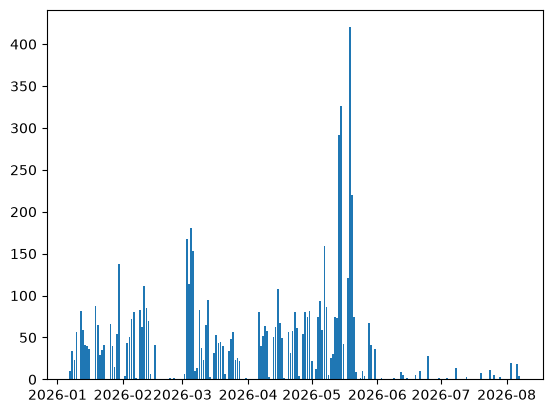

In [13]:
plt.bar(days,message_days)

Date
2026-01-07     2
2026-01-08    23
2026-01-09    19
2026-01-10    22
2026-01-12    22
              ..
2026-07-26     1
2026-07-29     2
2026-08-03    13
2026-08-06     9
2026-08-07     1
Name: Sender, Length: 132, dtype: int64


<BarContainer object of 132 artists>

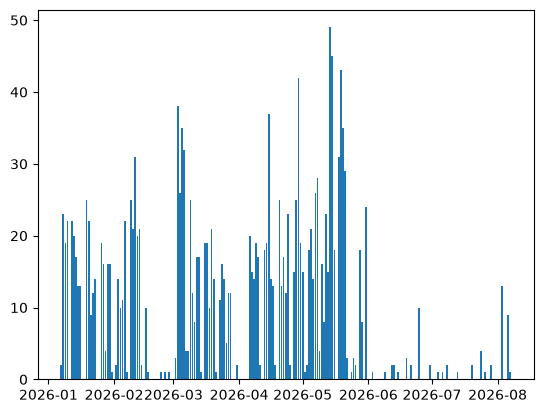

In [14]:
sender_days = history_26.groupby(['Date'])['Sender'].unique()
sender_days = sender_days.apply(lambda x: len(x))
print(sender_days)

plt.bar(sender_days.index, sender_days)

# Palabras más usadas.

Finalmente. Veremos cuales fueron las palabras más usadas dentro del grupo.

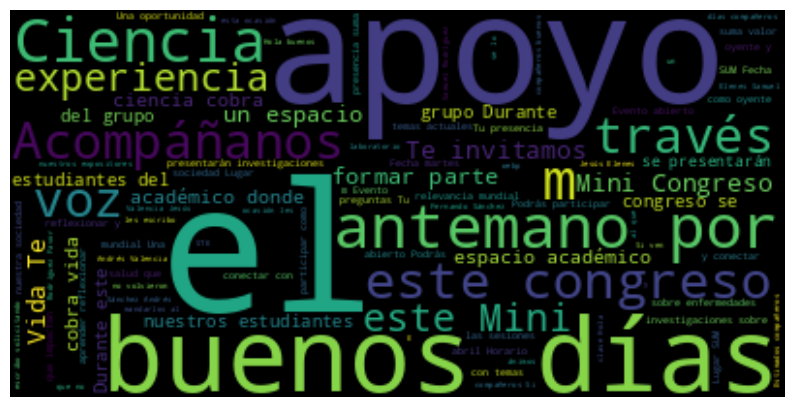

In [48]:
import wordcloud

def get_text(ID):
    text = []
    data = history_26[history_26['Sender']==ID]
    n_id = data.shape[0]
    if n_id == 0:
        return 0
    for v in data['Text']:
        text += v
    chat = " ".join(text)
    chat = regex.sub(f"{ID}:", "", chat)
    return chat

chat_16 = get_text("ID16")

palabras_paro = ['jpg', 'Media', 'de', 'la', 'file', 'attached', 'a', 'omitted', 'su', 'IMG', 'Muchas', 'gracias', 'para', 'en']

# Generamos la nube de palabras
wc = wordcloud.WordCloud(
    stopwords=palabras_paro
).generate(chat_16)

# Mostramos la nube de palabras
plt.figure(figsize=(10, 10))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()


Ahora hacemos el caso general.

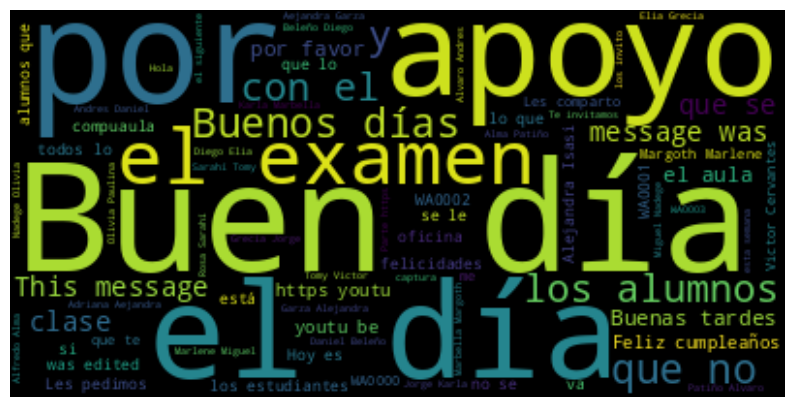

In [53]:
ids = list(history_26['Sender'].unique())[1:]
group_chat = ""
for i in ids:
    text = get_text(i)
    group_chat += text

wc = wordcloud.WordCloud(
    stopwords=palabras_paro
).generate(group_chat)

# Mostramos la nube de palabras
plt.figure(figsize=(10, 10))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

